# Additional Custom CNN — Maurice
NIH/NLM malaria cell classification: **Uninfected = 0, Parasitized = 1**.

A reproducible workflow using the team's committed 70/15/15 manifests (seed 42).
The model is trained from scratch with plain convolution blocks and no residual connections.
This notebook contains executable analysis, not measured results: fill interpretation prompts after running.

Run with the **Python (Malaria CNN)** kernel. Install `requirements.txt` in that environment first.
Place independently obtained images in `data/cell_images/{Uninfected,Parasitized}`. No download or split regeneration occurs.
Training eight runs can take hours; run individual configurations first when checking your setup.

## 1. Environment verification

In [13]:
import sys
from pathlib import Path
import importlib.util
import platform

candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next((p for p in candidates if (p / "src/config.py").is_file()
             and (p / "members/maurice_custom_cnn").is_dir()), None)
if ROOT is None:
    raise RuntimeError("Start Jupyter inside the project checkout.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
missing = [m for m in ["tensorflow", "tensorboard", "numpy", "pandas", "PIL", "sklearn", "matplotlib"]
           if importlib.util.find_spec(m) is None]
if missing:
    raise RuntimeError(f"Missing {missing}. Install requirements.txt using this kernel's Python: {sys.executable}")
print("Project:", ROOT, "\nPython:", platform.python_version(), "\nKernel:", sys.executable)

Project: /home/maurice/Documents/Intro_ML/Formative2_group_assignment/malaria_diagnosis_cnn 
Python: 3.13.15 
Kernel: /home/maurice/Documents/Intro_ML/Formative2_group_assignment/malaria_diagnosis_cnn/.venv/bin/python


## 2. Imports

In [14]:
import json
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
from IPython.display import display
from src.config import DATASET_DIR, SPLIT_DIR, RANDOM_SEED, CLASS_MAPPING, set_random_seed
from src.data_utils import build_dataframe, build_tf_dataset
from src.eval_utils import evaluate_binary, plot_confusion_matrix, plot_roc_curve
from src.gradcam_utils import make_gradcam_heatmap, overlay_heatmap
from members.maurice_custom_cnn.model import build_model, gradcam_model
from members.maurice_custom_cnn.train import (
    planned_experiments, make_datasets, make_model, compile_model, run_experiment,
    load_trained_model, freeze_selection, evaluate_on_test, split_identity, environment_snapshot,
)
set_random_seed(RANDOM_SEED)
print("TensorFlow:", tf.__version__, "GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0 GPUs: []


## 3. Configuration

In [15]:
MEMBER_ROOT = ROOT / "members/maurice_custom_cnn"
OUTPUT_ROOT = MEMBER_ROOT / "results"
FIG_DIR = MEMBER_ROOT / "figures"
CAM_DIR = MEMBER_ROOT / "gradcam"
LOG_ROOT = ROOT / "logs/fit"
for folder in (OUTPUT_ROOT, FIG_DIR, CAM_DIR):
    folder.mkdir(parents=True, exist_ok=True)
THRESHOLD = 0.5  # fixed in advance; any tuning must use validation only
CONFIGS = planned_experiments()
print(CLASS_MAPPING, "Seed:", RANDOM_SEED)

{'Uninfected': 0, 'Parasitized': 1} Seed: 42


## 4. Dataset loading
Discover filenames and verify the local layout. Inspect training images only in exploratory galleries.
Path disjointness does not establish patient independence or eliminate duplicate image content.
Verify source, usage terms, corruption, patient/slide grouping and duplicate risks with the team.
Do not replace the shared split to improve scores.

In [16]:
discovered = build_dataframe(DATASET_DIR)
display(discovered.groupby("label").size().rename("local_count").to_frame())
print("Local supported images:", len(discovered), "Expected from dataset notes: 27,558")

,local_count
label,
0,13779
1,13779


Local supported images: 27558 Expected from dataset notes: 27,558


## 5. Split loading
Read all three manifests for structural integrity only. Test pixels and predictions stay unused until final selection.
The dataset must match the manifests exactly; resolve missing files rather than silently dropping rows.

In [17]:
frames = {}
seen = set()
for name in ("train", "val", "test"):
    path = SPLIT_DIR / f"{name}_files.csv"
    if not path.exists():
        raise FileNotFoundError(f"Missing approved manifest: {path}. Obtain the shared CSVs from the team.")
    frame = pd.read_csv(path)
    assert {"filepath", "label"}.issubset(frame.columns) and not frame.empty
    assert not frame[["filepath", "label"]].isna().any().any()
    assert set(frame.label) == {0, 1} and not frame.filepath.duplicated().any()
    paths = set(frame.filepath)
    assert not (seen & paths), f"Overlap in {name}"
    for relative in paths:
        resolved = (ROOT / relative).resolve()
        assert not Path(relative).is_absolute() and resolved.is_relative_to(ROOT)
        assert resolved.is_file(), f"Missing dataset image: {relative}"
    seen.update(paths)
    frames[name] = frame
actual = dict(zip(discovered.filepath, discovered.label))
manifest_labels = {p: int(y) for frame in frames.values() for p, y in zip(frame.filepath, frame.label)}
assert actual == manifest_labels, "Local discovery and committed manifests differ."
split_table = pd.DataFrame({name: frame.label.value_counts().sort_index() for name, frame in frames.items()})
display(split_table)
print("Manifest SHA256:", split_identity())

,train,val,test
label,,,
0,9645,2067,2067
1,9645,2067,2067


Manifest SHA256: {'train': '31e5f2dad6cdf793df2d1339ce27664ed1083a02551a012e2253a76b0fcb48f3', 'val': '90501eb1ff5b3afd892e74d3e868def2f580c600daab5f2131490491770a442f', 'test': '8355c2720ec6d3311775d634e431db28bcdf026c223c697b8180eb74eca47123'}


## 6. Data pipeline
Shared utilities decode RGB, resize to the experiment resolution, and divide by 255 exactly once.
Only training is shuffled/augmented; validation and test preserve manifest order.
No full-dataset RAM cache is used. Keras augmentation receives float pixels in [0,255] before normalization.

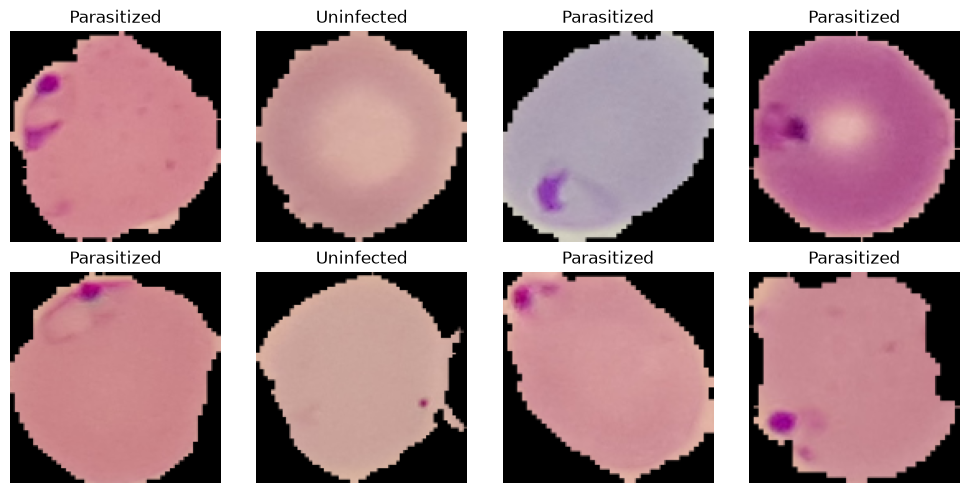

In [18]:
preview_ds = build_tf_dataset(frames["train"].head(8), batch_size=8)
images, labels = next(iter(preview_ds))
assert images.shape[-1] == 3 and labels.shape[-1] == 1
assert float(tf.reduce_min(images)) >= 0 and float(tf.reduce_max(images)) <= 1
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, image, label in zip(axes.flat, images.numpy(), labels.numpy().ravel()):
    ax.imshow(image); ax.set_title("Parasitized" if label else "Uninfected"); ax.axis("off")
plt.tight_layout(); plt.show(); plt.close(fig)
del preview_ds

## 7. Model definition
Each block has two 3×3 convolutions, optional batch normalization, ReLU and max pooling.
Global average pooling limits head parameters, followed by dropout and a single sigmoid output.
He initialization supports ReLU training; optional L2 regularizes convolution and output kernels.
The connected `last_conv` and `logit` outputs support Grad-CAM without sigmoid saturation.

The reusable implementation lives in `members/maurice_custom_cnn/model.py`.
Experiment 08 adds a fourth block; no pretrained weights or residual paths are used.

In [19]:
example_model = make_model(CONFIGS[0])
example_model.summary()
print("Input:", example_model.input_shape, "Output:", example_model.output_shape)

Model: "additional_custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalized_rgb (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu1 (ReLU)             │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu2 (ReLU)             │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu1 (ReLU)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu2 (ReLU)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu1 (ReLU)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu2 (ReLU)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pool             │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout (Dropout)          │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logit (Dense)                   │ (None, 1)              │           129 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ parasitized_probability         │ (None, 1)              │             0 │
│ (Activation)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 287,137 (1.10 MB)

 Trainable params: 287,137 (1.10 MB)

 Non-trainable params: 0 (0.00 B)

Input: (None, 128, 128, 3) Output: (None, 1)


## 8. Model compilation
Binary cross entropy matches a sigmoid infected-class probability. Full seven-metric evaluation uses saved ordered predictions; the training AUC is a streaming approximation.

In [20]:
compile_model(example_model, CONFIGS[0])
print("Compiled baseline with Adam, binary cross entropy, accuracy, precision, recall and AUC.")

Compiled baseline with Adam, binary cross entropy, accuracy, precision, recall and AUC.


## 9. Experiment configuration
Eight meaningful configurations are provided; seven completed runs are the assignment minimum.
Experiments 02 vs 01 and 03 vs 02 build up the baseline. Experiments 04–07 compare against 03.
Dropout/L2 in 03 and optimizer/learning rate in 06 are combined comparisons; attribution to a single factor is limited.
Experiment 08 is a combined candidate, not an isolated ablation. All receive the same seed and epoch budget.
Choose further hypotheses from validation evidence; no configuration guarantees best performance.

In [21]:
from dataclasses import asdict
experiment_table = pd.DataFrame([{ "run_name": cfg.run_name, **asdict(cfg)} for cfg in CONFIGS])
display(experiment_table)
experiment_table.to_csv(OUTPUT_ROOT / "planned_experiments.csv", index=False)

,run_name,number,description,hypothesis,image_size,filters,convolutions_per_block,use_batchnorm,dropout,l2,augmentation,optimizer,learning_rate,batch_size,epochs,patience,lr_schedule
0,additional_custom_cnn_exp_01_baseline,1,baseline,Establish the unregularized plain CNN baseline.,"(128, 128)","(32, 64, 128)",2,False,0.0,0.0000,False,adam,0.0010,32,25,5,False
1,additional_custom_cnn_exp_02_batchnorm,2,batchnorm,Batch normalization improves optimization vers...,"(128, 128)","(32, 64, 128)",2,True,0.0,0.0000,False,adam,0.0010,32,25,5,False
2,additional_custom_cnn_exp_03_dropout_l2,3,dropout_l2,Combined dropout and L2 reduce overfitting ver...,"(128, 128)","(32, 64, 128)",2,True,0.3,0.0001,False,adam,0.0010,32,25,5,False
3,additional_custom_cnn_exp_04_augmentation,4,augmentation,Orientation and scale variation improve genera...,"(128, 128)","(32, 64, 128)",2,True,0.3,0.0001,True,adam,0.0010,32,25,5,False
4,additional_custom_cnn_exp_05_lr_3e-4,5,lr_3e-4,A smaller Adam learning rate improves converge...,"(128, 128)","(32, 64, 128)",2,True,0.3,0.0001,False,adam,0.0003,32,25,5,False
5,additional_custom_cnn_exp_06_sgd_momentum,6,sgd_momentum,SGD with momentum and its specified learning r...,"(128, 128)","(32, 64, 128)",2,True,0.3,0.0001,False,sgd,0.0100,32,25,5,False
6,additional_custom_cnn_exp_07_batch64,7,batch64,A larger batch changes convergence and validat...,"(128, 128)","(32, 64, 128)",2,True,0.3,0.0001,False,adam,0.0010,64,25,5,False
7,additional_custom_cnn_exp_08_wider_aug_plateau,8,wider_aug_plateau,"A combined deeper, augmented, scheduled candid...","(128, 128)","(32, 64, 128, 256)",2,True,0.3,0.0001,True,adam,0.0010,32,25,5,True


## 10. TensorBoard setup
Every run reserves a unique directory using the shared callback, logs HParams, epoch metrics and seven validation metrics.
The runner also records environment packages, Git state, architecture, seed and manifest hashes.
Existing completed runs are reused only when configurations and manifests match; partial runs are preserved.

Run `tensorboard --logdir logs/fit` from the project root. Save comparison screenshots and share raw log directories through approved external storage for the report appendix.

In [22]:
snapshot = environment_snapshot()
print("Git:", snapshot["git_commit"], "Uncommitted changes:", snapshot["working_tree_dirty"])
print("TensorBoard root:", LOG_ROOT)
print("Run names:", *[cfg.run_name for cfg in CONFIGS], sep="\n")

Git: 34e762db4206647db0b1ec540e4df84aa9657c4a Uncommitted changes: True
TensorBoard root: /home/maurice/Documents/Intro_ML/Formative2_group_assignment/malaria_diagnosis_cnn/logs/fit
Run names:
additional_custom_cnn_exp_01_baseline
additional_custom_cnn_exp_02_batchnorm
additional_custom_cnn_exp_03_dropout_l2
additional_custom_cnn_exp_04_augmentation
additional_custom_cnn_exp_05_lr_3e-4
additional_custom_cnn_exp_06_sgd_momentum
additional_custom_cnn_exp_07_batch64
additional_custom_cnn_exp_08_wider_aug_plateau


## 11. Training
Run each experiment from a newly initialized model. Early stopping and checkpoint selection monitor validation loss.
Best weights are explicitly reloaded before validation predictions. No test dataset is built here.
For a setup check, use `CONFIGS[:1]`; return to all configurations to complete the experiment requirement.
Interrupted runs require a fresh experiment number, preserving existing evidence.

In [ ]:
import importlib
from members.maurice_custom_cnn import train as training

training = importlib.reload(training)

RUN_CONFIGS = CONFIGS
rows = [
    training.run_experiment(
        cfg, OUTPUT_ROOT, LOG_ROOT, restart_incomplete=True
    )
    for cfg in RUN_CONFIGS
]
summary = pd.DataFrame(rows).set_index("run_name")
summary.to_csv(OUTPUT_ROOT / "experiments_summary.csv")
display(summary.round(4))

Preserved incomplete run: /home/maurice/Documents/Intro_ML/Formative2_group_assignment/malaria_diagnosis_cnn/members/maurice_custom_cnn/results/archived_incomplete/additional_custom_cnn_exp_01_baseline_20261007T185313Z_50099b8fbfd84876a8864a1ed1eabb79
Preserved incomplete run: /home/maurice/Documents/Intro_ML/Formative2_group_assignment/malaria_diagnosis_cnn/logs/fit/archived_incomplete/additional_custom_cnn_exp_01_baseline_20261007T185313Z_50099b8fbfd84876a8864a1ed1eabb79
Epoch 1/25


/home/maurice/Documents/Intro_ML/Formative2_group_assignment/malaria_diagnosis_cnn/.venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


## 12. Evaluation — validation only
Rank by validation ROC-AUC, then F1 and specificity. Examine sensitivity, specificity and learning curves together before selecting.
The best epoch within each run is selected by validation loss; the best experiment uses the comparison below.
Keep the threshold at 0.5 unless you document a validation-only threshold-selection procedure before freezing.

In [ ]:
ranking = summary.sort_values(["val_roc_auc", "val_f1", "val_specificity"], ascending=False)
display(ranking[["val_accuracy", "val_precision", "val_recall", "val_f1", "val_roc_auc",
                 "val_sensitivity", "val_specificity", "best_epoch", "parameters", "train_minutes"]])
print("Leading validation candidate:", ranking.index[0])

## 13. Visualization — validation learning curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for run in summary.index:
    history = pd.read_csv(OUTPUT_ROOT / run / "history.csv")
    epochs = history.epoch + 1
    axes[0].plot(epochs, history.val_accuracy, label=run.replace("additional_custom_cnn_", ""))
    axes[1].plot(epochs, history.val_loss, label=run.replace("additional_custom_cnn_", ""))
for ax, title in zip(axes, ["Validation accuracy", "Validation loss"]):
    ax.set(title=title, xlabel="Epoch"); ax.legend(fontsize=7)
fig.tight_layout(); fig.savefig(FIG_DIR / "validation_comparison.png", dpi=250)
plt.show(); plt.close(fig)
CANDIDATE = ranking.index[0]
history = pd.read_csv(OUTPUT_ROOT / CANDIDATE / "history.csv")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ["accuracy", "loss"]):
    ax.plot(history.epoch + 1, history[metric], label="Training")
    ax.plot(history.epoch + 1, history[f"val_{metric}"], label="Validation")
    ax.axvline(int(summary.loc[CANDIDATE, "best_epoch"]), ls="--", color="gray", label="Best epoch")
    ax.set(title=metric.capitalize(), xlabel="Epoch"); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / f"{CANDIDATE}_curves.png", dpi=250)
plt.show(); plt.close(fig)

**Interpret after execution:** Which runs overfit or underfit? Compare train/validation gaps and loss trends at the restored epoch. Augmented training accuracy and unaugmented validation accuracy are measured under different conditions. A small gap alone does not establish generalization.

## 14. Grad-CAM — validation examples
Inspect correctly classified infected and uninfected cells and false positives/negatives where available.
Explanations target the **predicted class logit**: z for infected and −z for uninfected.
Representative categories are sampled with a fixed seed. Heatmaps indicate model attribution, not verified parasite localization.

In [ ]:
def annotate_predictions(frame, threshold):
    return frame.assign(predicted=(frame.probability >= threshold).astype(int)).assign(
        correct=lambda x: x.predicted == x.label)

candidate_model, candidate_cfg = load_trained_model(CANDIDATE, OUTPUT_ROOT)
val_predictions = annotate_predictions(pd.read_csv(OUTPUT_ROOT / CANDIDATE / "val_predictions.csv"), THRESHOLD)

def show_gradcam(model, cfg, predictions, prefix):
    groups = {
        "correct_infected": predictions[(predictions.label == 1) & predictions.correct],
        "correct_uninfected": predictions[(predictions.label == 0) & predictions.correct],
        "false_negative": predictions[(predictions.label == 1) & ~predictions.correct],
        "false_positive": predictions[(predictions.label == 0) & ~predictions.correct],
    }
    feature_model = gradcam_model(model)
    records = []
    for category, group in groups.items():
        if group.empty:
            print("No example available:", category); continue
        row = group.sample(1, random_state=RANDOM_SEED).iloc[0]
        with Image.open(ROOT / row.filepath) as im:
            original = np.asarray(im.convert("RGB"))
        resized = tf.image.resize(tf.cast(original, tf.float32), tuple(cfg.image_size)) / 255.0
        heatmap = make_gradcam_heatmap(model, resized, feature_model=feature_model,
                                      class_index=int(row.predicted), from_logits=True)
        overlay = overlay_heatmap(original, heatmap)
        fig, axes = plt.subplots(1, 3, figsize=(10, 3))
        for ax, img, title in zip(axes, [original, heatmap, overlay], ["Original", "Attribution", "Overlay"]):
            ax.imshow(img); ax.set_title(title); ax.axis("off")
        fig.suptitle(f"{category}: true={row.label}, predicted={row.predicted}, P(infected)={row.probability:.3f}")
        filename = f"{prefix}_{category}.png"
        fig.tight_layout(); fig.savefig(CAM_DIR / filename, dpi=250)
        plt.show(); plt.close(fig)
        records.append(dict(category=category, filepath=row.filepath, label=int(row.label),
                            predicted=int(row.predicted), probability=float(row.probability),
                            heatmap=filename, interpretation="Complete after visual inspection"))
    pd.DataFrame(records).to_csv(CAM_DIR / f"{prefix}_examples.csv", index=False)

show_gradcam(candidate_model, candidate_cfg, val_predictions, f"{CANDIDATE}_validation")

**Interpret after execution:** Does attention fall on intracellular structures, staining, cell boundaries or background? Compare correct and incorrect examples. Record observations and uncertainties in `members/maurice_custom_cnn/error_analysis.md`; avoid claiming biological localization from heatmaps alone.

## 15. Error analysis — validation

In [ ]:
def error_analysis(predictions, prefix):
    errors = predictions[~predictions.correct].copy()
    errors["error_type"] = np.where(errors.label == 1, "false_negative", "false_positive")
    errors["predicted_class_confidence"] = np.where(errors.predicted == 1, errors.probability, 1-errors.probability)
    errors = errors.sort_values("predicted_class_confidence", ascending=False)
    errors["possible_cause"] = "Pending visual inspection"
    errors.to_csv(OUTPUT_ROOT / f"{prefix}_errors.csv", index=False)
    display(errors.head(12))
    print("False negatives:", int(((predictions.label == 1) & ~predictions.correct).sum()),
          "False positives:", int(((predictions.label == 0) & ~predictions.correct).sum()))
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for ax in axes.flat:
        ax.axis("off")
    for ax, (_, row) in zip(axes.flat, errors.head(8).iterrows()):
        with Image.open(ROOT / row.filepath) as im:
            ax.imshow(im.convert("RGB"))
        ax.set_title(f"{row.error_type}\np={row.probability:.3f}")
    fig.tight_layout(); fig.savefig(FIG_DIR / f"{prefix}_errors.png", dpi=250)
    plt.show(); plt.close(fig)
    return errors

validation_errors = error_analysis(val_predictions, f"{CANDIDATE}_validation")

**Complete from observed evidence:** Record filename, true/predicted label, probability, threshold, heatmap, possible cause and uncertainty. Consider tiny/faint structures, staining artifacts and ambiguous labels as hypotheses, not established causes. Relate attempted changes to controlled validation results. After test evaluation, further improvements require a new independent evaluation set.

## 16. Final experiment selection and held-out evaluation
Freeze selection **before** reading test images. Fill a validation-based rationale after reviewing metrics, training curves and errors.
The default candidate is the validation ranking leader; change it only with a documented validation-based reason.
The stored selection binds run, threshold, manifest hashes and checkpoint hash. Subsequent execution loads cached test predictions instead of predicting again.

Training is necessary before running this section; no best run or performance is claimed in advance.

In [ ]:
FINAL_RUN = CANDIDATE
SELECTION_RATIONALE = ""  # Fill with observed validation evidence, tradeoffs and comparison run names.
selection = freeze_selection(FINAL_RUN, OUTPUT_ROOT, threshold=THRESHOLD,
                             rationale=SELECTION_RATIONALE)
display(pd.Series(selection))

In [ ]:
test_metrics, test_predictions = evaluate_on_test(OUTPUT_ROOT, LOG_ROOT)
test_predictions = annotate_predictions(test_predictions, selection["threshold"])
display(pd.Series(test_metrics, name="held_out_test").to_frame())
y_true, y_prob = test_predictions.label.to_numpy(), test_predictions.probability.to_numpy()
fig, _ = plot_confusion_matrix(y_true, y_prob, threshold=selection["threshold"],
                              output_path=FIG_DIR / f"{FINAL_RUN}_test_confusion.png")
plt.show(); plt.close(fig)
fig, _, _ = plot_roc_curve(y_true, y_prob, output_path=FIG_DIR / f"{FINAL_RUN}_test_roc.png")
plt.show(); plt.close(fig)
final_model, final_cfg = load_trained_model(FINAL_RUN, OUTPUT_ROOT)
show_gradcam(final_model, final_cfg, test_predictions, f"{FINAL_RUN}_test")
test_errors = error_analysis(test_predictions, f"{FINAL_RUN}_test")

### Final interpretation and submission
Complete these items after execution:

- Explain the selected experiment using validation evidence; compare all seven required metrics on the frozen test set.
- Describe false negatives/positives, learning curves and Grad-CAM observations with paths to saved evidence.
- Complete `experiments_log.md` for each run and `error_analysis.md` from the generated CSVs and figures.
- Record failed hypotheses as well as improvements. Do not present planned runs as completed.
- Discuss image-level split limitations, uncertain patient independence, duplicate risk, dataset provenance and performance variability across seeds. Image classification metrics do not establish clinical diagnostic utility.
- Integrate Maurice's report contribution and citations; use the team submission checklist for remaining deliverables.
- Share raw TensorBoard logs externally and add their viewable link and comparison screenshots to the report appendix.

Artifacts: `members/maurice_custom_cnn/results/` (configs, package snapshot, weights, histories, metrics and predictions), `figures/`, `gradcam/`, and `logs/fit/<run_name>/`. These generated artifacts are ignored by Git. This notebook intentionally has no embedded execution outputs.